In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/marketing_campaign.csv', sep='\t')

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
print("Shape:", df.shape)

Shape: (2240, 29)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [ ]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df['Dt_Customer'] = pd.to_datetime(
    df['Dt_Customer'],
    dayfirst=True
)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2240 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


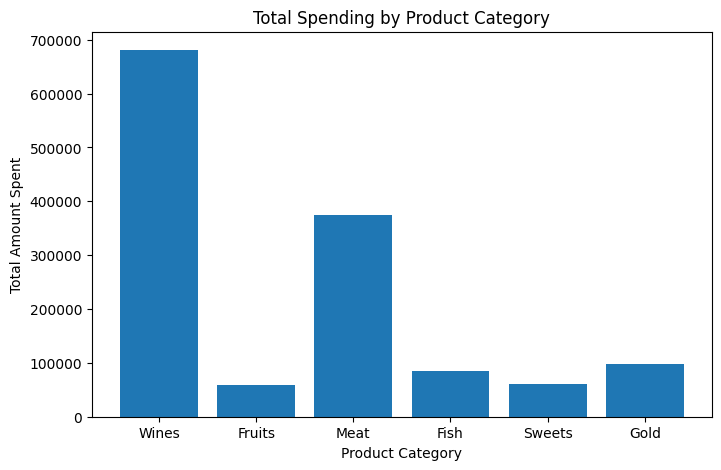

In [ ]:
import matplotlib.pyplot as plt

products = {
    'Wines': df['MntWines'].sum(),
    'Fruits': df['MntFruits'].sum(),
    'Meat': df['MntMeatProducts'].sum(),
    'Fish': df['MntFishProducts'].sum(),
    'Sweets': df['MntSweetProducts'].sum(),
    'Gold': df['MntGoldProds'].sum()
}

plt.figure(figsize=(8,5))
plt.bar(products.keys(), products.values())
plt.title('Total Spending by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount Spent')
plt.show()

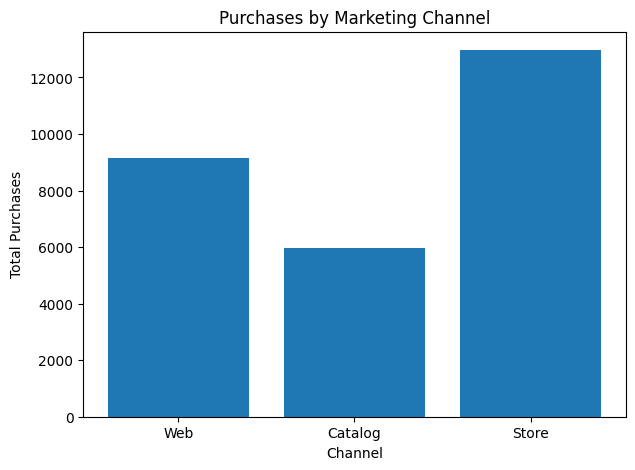

In [ ]:
import matplotlib.pyplot as plt

channels = {
    'Web': df['NumWebPurchases'].sum(),
    'Catalog': df['NumCatalogPurchases'].sum(),
    'Store': df['NumStorePurchases'].sum()
}

plt.figure(figsize=(7,5))
plt.bar(channels.keys(), channels.values())
plt.title('Purchases by Marketing Channel')
plt.xlabel('Channel')
plt.ylabel('Total Purchases')
plt.show()

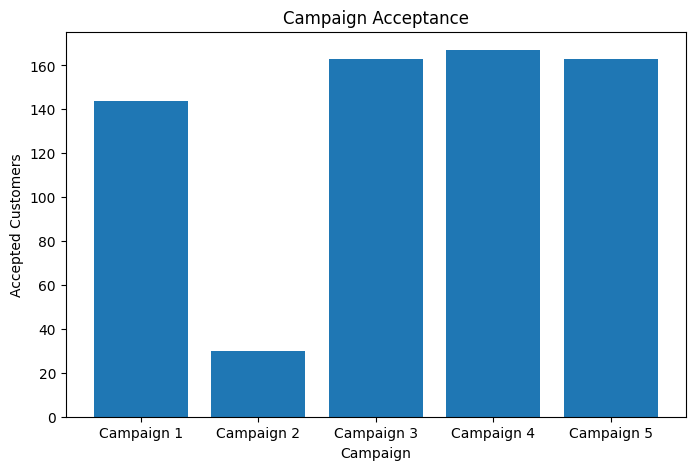

In [ ]:
campaigns = {
    'Campaign 1': df['AcceptedCmp1'].sum(),
    'Campaign 2': df['AcceptedCmp2'].sum(),
    'Campaign 3': df['AcceptedCmp3'].sum(),
    'Campaign 4': df['AcceptedCmp4'].sum(),
    'Campaign 5': df['AcceptedCmp5'].sum()
}

plt.figure(figsize=(8,5))
plt.bar(campaigns.keys(), campaigns.values())
plt.title('Campaign Acceptance')
plt.xlabel('Campaign')
plt.ylabel('Accepted Customers')
plt.show()

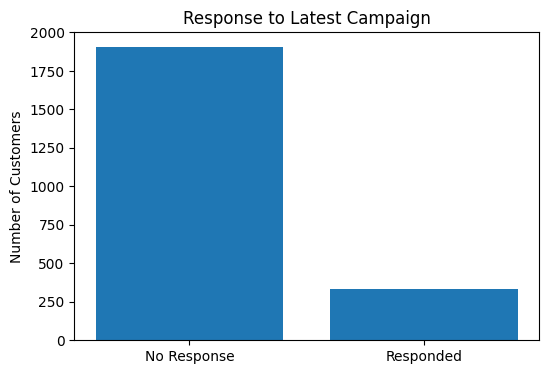

In [ ]:
response = df['Response'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(['No Response', 'Responded'], response.values)
plt.title('Response to Latest Campaign')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

In [ ]:
print(df[['Total_Spending']].head())

   Total_Spending
0            1617
1              27
2             776
3              53
4             422


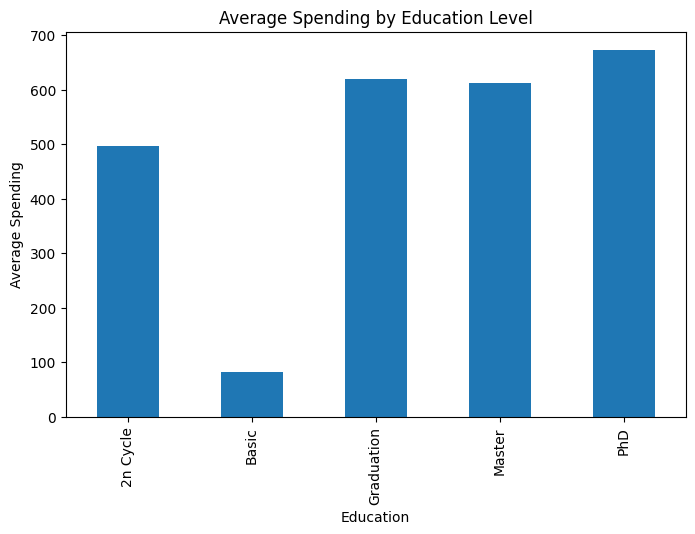

In [ ]:
education_spending = df.groupby('Education')['Total_Spending'].mean()

plt.figure(figsize=(8,5))
education_spending.plot(kind='bar')
plt.title('Average Spending by Education Level')
plt.xlabel('Education')
plt.ylabel('Average Spending')
plt.show()

In [ ]:
df.to_csv('marketing_campaign_cleaned.csv', index=False)

In [ ]:
from google.colab import files

files.download('marketing_campaign_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>